## <center> Project: The CMS National Hospital Performance Audit

In the world of healthcare data science, the most dangerous assumption is that "standardized" data is "clean" data. Your task is to act as a Data Consultant for a major health insurance provider. They want to know if they are paying more for higher-quality care, or if cost and quality are entirely decoupled in the current US hospital landscape

The data we are using is from CMS portal

**Note to Professor: Please use the attached requirements.txt file to set up your virtual environment (.venv). This will ensure that all dependencies are correctly installed and the code runs as expected. Thank you**

## <center> Phase I: The Unified View (Merging)

#### <center> Install Necessary Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')


import requests, zipfile, io, os
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
import re, gc
import plotly.express as px

#### <center> Loading the Data

In [2]:
# Configuration: Defining the source URL and target local directory
url = "https://data.cms.gov/provider-data/sites/default/files/archive/Hospitals/current/hospitals_current_data.zip"
extract_to_folder = "data"

# Connection Protocol: Standard browser signature to prevent errors
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

# Ensuring the target directory exists before downloading
os.makedirs(extract_to_folder, exist_ok=True)

# Fetch the latest file from the server
print("Downloading file...")
# Headers parameter here to present as a standard browser
response = requests.get(url, headers=headers)
response.raise_for_status()

# Extract the downloaded zip content into the target folder
print("Extracting files...")
with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
    zip_ref.extractall(extract_to_folder)
    
print("Download and extraction complete!")

Extracting files...
Download and extraction complete!


### <center> Load Data

In [3]:
# Load specific files into unique variables; We use os.path.join to combine the folder name with the specific filename

# Try to safely extract and isolate specific hospital metrics into dedicated DataFrames for downstream analytical merging.
try:
    # Enforce 'Facility ID' as a string to prevent pandas from stripping leading zeros.
    # Hospital IDs (like '010001') act as our primary join keys and must preserve exact text formatting.
    dtype_settings = {'Facility ID': str,
                      'ZIP Code':str,
                      }
    
    # Load datasets using 'latin-1' encoding to cleanly handle unexpected special 
    # characters or symbols common in healthcare facility names and addresses without crashing.
    # Using os.path so that I can work using both Windows and Linux (handles filepath issues)
    data_gen_info = pd.read_csv(
        os.path.join(extract_to_folder, "Hospital_General_Information.csv"), 
        encoding='latin-1', 
        dtype=dtype_settings
    )
  
    data_spending = pd.read_csv(
        os.path.join(extract_to_folder, "Medicare_Hospital_Spending_Per_Patient-Hospital.csv"), 
        encoding='latin-1', 
        dtype=dtype_settings
    )
    
    data_complications = pd.read_csv(
        os.path.join(extract_to_folder, "Complications_and_Deaths-Hospital.csv"), 
        encoding='latin-1', 
        dtype=dtype_settings
    )

    print("DataFrames loaded successfully!")

    # Provide an immediate sanity check on dataset volume. 
    # If a row count returns 0, it signals a potential upstream data corruption or extraction issue.
    print(f"General Info Rows: {len(data_gen_info)}")
    print(f"Spending Rows: {len(data_spending)}")
    print(f"Complications Rows: {len(data_complications)}")

# Gracefully handle structural or environmental failures without breaking the entire execution pipeline.
except FileNotFoundError as e:
    print(f"Error: Could not find the file. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

DataFrames loaded successfully!
General Info Rows: 5432
Spending Rows: 4628
Complications Rows: 95840


#### <center> Viewing the data

In [4]:
# # Optimize the pandas terminal/notebook output container to maximize visibility during data exploration.
# # I use this section of code often and usually deactivate it all before I upload / send

# # -- Force pandas to render every single column side-by-side.
# pd.set_option('display.max_columns', None) # Column limit; uncomment if required

# # -- Force pandas to render every single row.
# #pd.set_option('display.max_rows', None) # Row Limit; uncomment if required

# # -- Forces the system to utilize the full horizontal space available instead of wrapping text prematurely.
# pd.set_option('display.width', None) # Width limit; uncomment if required

# # -- Limit for float decimal precision
# # pd.set_option('display.float_format', lambda x: '%.2f' % x) # Float decimal display limit; uncomment if required

# # -- Disable character truncation inside individual cells
# pd.set_option('display.max_colwidth', None) # Set max column width; uncomment if required

# # I sometimes use these while exploring the data to make the process less painful

In [5]:
# Defining string print header function for neater output
# Serves as a standardized visual separator when printing multiple dataframes back-to-back

def print_header(title, width=60):
    print("\n" + "=" * width)
    print(title.center(width))
    print("=" * width)

In [6]:
# Display first row of each of the 3 datasets, to get a glimpse of what to expect

print("Printing...")

print_header("General file - First row",100)
display(data_gen_info.head(1))

print_header("Financial file - First row",100)
display(data_spending.head(1))

print_header("Complications file - First row",100)
display(data_complications.head(1))

Printing...

                                      General file - First row                                      


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,1,9,1,NaN,15,15,NaN,10,10,NaN



                                     Financial file - First row                                     


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Measure ID,Measure Name,Score,Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MSPB-1,Medicare hospital spending per patient (Medica...,0.99,NaN,01/01/2024,12/31/2024



                                   Complications file - First row                                   


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Measure ID,Measure Name,Compared to National,Denominator,Score,Lower Estimate,Higher Estimate,Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,COMP_HIP_KNEE,Rate of complications for hip/knee replacement...,No Different Than the National Rate,27,3.2,1.7,5.9,NaN,04/01/2021,03/31/2024


In [7]:
# Checking data types (.dtypes) ensures that keys match for future joins (e.g., strings vs integers) 
# and identifies columns that contain numeric data but were mistakenly parsed as objects due to missing/dirty data.

print("Printing info files...")

print_header("General - Info")
display(data_gen_info.dtypes)

print_header("Financial - Info")
display(data_spending.dtypes)

print_header("Complications - Info")
display(data_complications.dtypes)

# I have written a function for another project that I will adapt here so that I can view this info in a better way

Printing info files...

                       General - Info                       


Facility ID                                             str
Facility Name                                           str
Address                                                 str
City/Town                                               str
State                                                   str
ZIP Code                                                str
County/Parish                                           str
Telephone Number                                        str
Hospital Type                                           str
Hospital Ownership                                      str
Emergency Services                                      str
Meets criteria for birthing friendly designation        str
Hospital overall rating                                 str
Hospital overall rating footnote                        str
MORT Group Measure Count                                str
Count of Facility MORT Measures                         str
Count of MORT Measures Better           


                      Financial - Info                      


Facility ID             str
Facility Name           str
Address                 str
City/Town               str
State                   str
ZIP Code                str
County/Parish           str
Telephone Number        str
Measure ID              str
Measure Name            str
Score                   str
Footnote            float64
Start Date              str
End Date                str
dtype: object


                    Complications - Info                    


Facility ID             str
Facility Name           str
Address                 str
City/Town               str
State                   str
ZIP Code                str
County/Parish           str
Telephone Number        str
Measure ID              str
Measure Name            str
Compared to National    str
Denominator             str
Score                   str
Lower Estimate          str
Higher Estimate         str
Footnote                str
Start Date              str
End Date                str
dtype: object

#### <center> Preparing data for Merge

In [8]:
# Evaluating the data distribution of 'Measure ID' in the financial dataset.
# We check value counts to determine if this file contains diverse sub-metrics or if it is 
# homogeneous enough to safely drop structural category columns prior to our main merge.

display(data_spending["Measure ID"].value_counts())

# No other values, can proceed with dropping these columns for merge

Measure ID
MSPB-1    4628
Name: count, dtype: int64

In [9]:
# Evaluating the data distribution of 'Measure ID' in the complications dataset.
# Because this file tracks multiple clinical conditions, we count occurrences to pinpoint the exact 
# indicator labels before stripping out irrelevant rows.

data_complications["Measure ID"].value_counts()

Measure ID
COMP_HIP_KNEE    4792
Hybrid_HWM       4792
MORT_30_AMI      4792
MORT_30_CABG     4792
MORT_30_COPD     4792
MORT_30_HF       4792
MORT_30_PN       4792
MORT_30_STK      4792
PSI_03           4792
PSI_04           4792
PSI_06           4792
PSI_08           4792
PSI_09           4792
PSI_10           4792
PSI_11           4792
PSI_12           4792
PSI_13           4792
PSI_14           4792
PSI_15           4792
PSI_90           4792
Name: count, dtype: int64

In [10]:
# Keeping only Hybrid_HWM for complications file

# Filter for the specific mortality measure
data_complications = data_complications[data_complications['Measure ID'] == 'Hybrid_HWM'].reset_index(drop=True)

In [11]:
# Checking value distributions helps us understand the structure of categorical data.
# This is useful for identifying dominant categories, spotting inconsistencies,
# detecting imbalanced data, and deciding how columns may need to be cleaned,
# grouped, filtered, or analyzed later in the project.

print("Complications dataset - Checking value counts...\n")

print_header("Medical complications, [Measure Name] - Value Counts",80)
display(data_complications["Measure Name"].value_counts())

print_header("Medical complications, [Compared to National] - Value Counts",80)
display(data_complications["Compared to National"].value_counts())

Complications dataset - Checking value counts...


              Medical complications, [Measure Name] - Value Counts              


Measure Name
Hybrid Hospital-Wide All-Cause Risk Standardized Mortality Rate    4792
Name: count, dtype: int64


          Medical complications, [Compared to National] - Value Counts          


Compared to National
No Different Than the National Rate    3557
Not Available                           459
Number of Cases Too Small               357
Better Than the National Rate           300
Worse Than the National Rate            119
Name: count, dtype: int64

#### <center> Removing redundant columns

In [12]:
# Keep columns from index 0 up to, but not including, next number
# data_gen_info = data_gen_info.loc[:, :data_gen_info.columns[12]]

In [13]:
# Remove columns that are not required for the merge or later analysis.
# These columns mainly contain duplicated hospital identity/contact information
# that exists in both datasets and would create unnecessary redundancy after merging.

cols_to_remove_spending_and_complications = [
    "Facility Name", "Address", "City/Town", "State", "ZIP Code",
     "County/Parish", "Telephone Number", "Measure ID", "Measure Name", "Footnote"
]

# Drop unnecessary columns from both datasets using the `columns=` parameter.
# This keeps the datasets cleaner and reduces memory usage before merging.

data_spending = data_spending.drop(columns = cols_to_remove_spending_and_complications)
data_complications = data_complications.drop(columns = cols_to_remove_spending_and_complications)

#### Renaming columns

In [14]:
# Spending sheet - Dropping the 'Measure Name' column; 
# We rename the Score column inside the Spending sheet to reflect that it is MSPB
data_spending = data_spending.rename(
        columns={'Score': 'MSPB_score',
                 'Start Date':'MSPB_start_date',
                 'End Date':'MSPB_end_date',
                 }
)

# Complications sheet - Dropping the 'Measure Name' column; 
# We rename the Score column inside the Spending sheet to reflect that it is from its respective sheet
data_complications = data_complications.rename(
        columns={'Compared to National': 'Complications_compared_to_national',
                 'Denominator':'Complications_denominator',
                 'Score':'Complications_score',
                 'Lower Estimate':'Complications_lower_estimate',
                 'Higher Estimate':'Complications_higher_estimate',
                 'Start Date':'Complications_start_date',
                 'End Date':'Complications_end_date'
                 }
)

print_header("Printing Financial file")
display(data_spending.head())
print_header("Printing Complications file")
display(data_complications.head())
print("Final datasets before merge, Headers renamed to include original file name to keep track")


                  Printing Financial file                   


,Facility ID,MSPB_score,MSPB_start_date,MSPB_end_date
0,010001,0.99,01/01/2024,12/31/2024
1,010005,1.00,01/01/2024,12/31/2024
2,010006,1.01,01/01/2024,12/31/2024
3,010007,1.04,01/01/2024,12/31/2024
4,010011,0.96,01/01/2024,12/31/2024



                Printing Complications file                 


,Facility ID,Complications_compared_to_national,Complications_denominator,Complications_score,Complications_lower_estimate,Complications_higher_estimate,Complications_start_date,Complications_end_date
0,010001,No Different Than the National Rate,1835,4.5,2.6,7.4,07/01/2023,06/30/2024
1,010005,No Different Than the National Rate,698,4.6,2.5,8.3,07/01/2023,06/30/2024
2,010006,No Different Than the National Rate,1583,5.2,3.1,8.4,07/01/2023,06/30/2024
3,010007,No Different Than the National Rate,125,4.8,2.3,9.6,07/01/2023,06/30/2024
4,010011,No Different Than the National Rate,582,4.1,2.3,7.0,07/01/2023,06/30/2024


Final datasets before merge, Headers renamed to include original file name to keep track


#### <center> Merging

In [15]:
# Precheck main file
data_gen_info.head()

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,1,9,1,NaN,15,15,NaN,10,10,NaN
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,1,8,0,NaN,15,15,NaN,10,10,NaN
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,1,8,0,NaN,15,15,NaN,10,9,NaN
3,010007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,Acute Care Hospitals,Voluntary non-profit - Private,...,0,3,2,NaN,15,5,NaN,10,7,NaN
4,010011,ST. VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,JEFFERSON,(205) 838-3122,Acute Care Hospitals,Voluntary non-profit - Private,...,1,5,2,29.0,15,10,29.0,10,7,29.0


In [16]:
# Capture row counts before merging
count_gen = len(data_gen_info)
count_fin = len(data_spending)

# Perform the merge
# 'inner' merge if we only want hospitals that have BOTH info and financials.
# how='left' if we want to keep all hospitals regardless of financial data.
data_merge_gen_and_financials = pd.merge(
    data_gen_info,
    data_spending,
    on='Facility ID',
    how='left' 
)

# Capture row count after merging
count_final = len(data_merge_gen_and_financials)

# Report the results
print("--- Merge Report ---")
print(f"Rows in General Info: {count_gen}")
print(f"Rows in Financials:   {count_fin}")
print(f"Rows in Merged File:  {count_final}")

# Calculate and print drops
dropped_gen = count_gen - count_final
if dropped_gen > 0:
    print(f"NOTE: {dropped_gen} hospitals from General Info were dropped (no matching Financial ID).")
else:
    print("All hospitals from General Info were successfully matched.")

# Check for duplicates (safety check)
if count_final > count_gen:
    print(f"WARNING: Row count increased by {count_final - count_gen}. Check for duplicate Facility IDs!")

--- Merge Report ---
Rows in General Info: 5432
Rows in Financials:   4628
Rows in Merged File:  5432
All hospitals from General Info were successfully matched.


In [17]:
# Capture row counts before merging
count_prev_merge = len(data_merge_gen_and_financials)
count_complications = len(data_complications)

# Performing the merge
# Left outer merge
data_merge_final = pd.merge(
    data_merge_gen_and_financials,
    data_complications,
    on='Facility ID',
    how='left' 
)

# Capture row count after merging
count_final = len(data_merge_final)

# Report the results
print("--- Merge Report ---")
print(f"Rows in prev merge: {count_prev_merge}")
print(f"Rows in complications:   {count_complications}")
print(f"Rows in final merged file:  {count_final}")

# Calculate and print drops
dropped_gen = count_prev_merge - count_final
if dropped_gen > 0:
    print(f"NOTE: {dropped_gen} hospitals from prev merge dropped (no matching Financial ID).")
else:
    print("All hospitals from prev merge were successfully matched.")

# Check for duplicates (safety check)
if count_final > count_prev_merge:
    print(f"WARNING: Row count increased by {count_final - count_prev_merge}. Check for duplicate Facility IDs!")

data_master = data_merge_final.copy()

 

--- Merge Report ---
Rows in prev merge: 5432
Rows in complications:   4792
Rows in final merged file:  5432
All hospitals from prev merge were successfully matched.


In [18]:
# Printing to check
data_master.head()

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,MSPB_score,MSPB_start_date,MSPB_end_date,Complications_compared_to_national,Complications_denominator,Complications_score,Complications_lower_estimate,Complications_higher_estimate,Complications_start_date,Complications_end_date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,0.99,01/01/2024,12/31/2024,No Different Than the National Rate,1835,4.5,2.6,7.4,07/01/2023,06/30/2024
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,1.00,01/01/2024,12/31/2024,No Different Than the National Rate,698,4.6,2.5,8.3,07/01/2023,06/30/2024
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,1.01,01/01/2024,12/31/2024,No Different Than the National Rate,1583,5.2,3.1,8.4,07/01/2023,06/30/2024
3,010007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,Acute Care Hospitals,Voluntary non-profit - Private,...,1.04,01/01/2024,12/31/2024,No Different Than the National Rate,125,4.8,2.3,9.6,07/01/2023,06/30/2024
4,010011,ST. VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,JEFFERSON,(205) 838-3122,Acute Care Hospitals,Voluntary non-profit - Private,...,0.96,01/01/2024,12/31/2024,No Different Than the National Rate,582,4.1,2.3,7.0,07/01/2023,06/30/2024


## <center> Phase II: The "Janitor" Protocol (Cleaning & Encoding)

In [19]:
# Checking variables in memory
%who

cols_to_remove_spending_and_complications	 count_complications	 count_fin	 count_final	 count_gen	 count_prev_merge	 data_complications	 data_gen_info	 data_master	 
data_merge_final	 data_merge_gen_and_financials	 data_spending	 display	 dropped_gen	 dtype_settings	 extract_to_folder	 gc	 headers	 
io	 np	 os	 pd	 plt	 print_header	 px	 re	 requests	 
response	 sns	 url	 warnings	 zip_ref	 zipfile	 


In [20]:
# # Deleting variables that will not be used from this point onwards in this notebook

del data_merge_gen_and_financials
del count_complications
del data_complications
del data_gen_info
del data_spending
del data_merge_final

# Tell Python to clean up the memory
gc.collect()

print("Variables deleted and memory cleared!")

Variables deleted and memory cleared!


### <center> Taking a subset, keeping only necessary columns

In [21]:
# # I would usually prefer to drop the columns at an earlier stage for better performance
# # but stuck with this approach for this particular project

# # Create a new DataFrame with only the selected columns
# data = data_master[[
#     'Facility ID',
#     'Facility Name',
#     'County/Parish',
#     'City/Town',
#     'State',
#     'Hospital Type',
#     'Hospital Ownership',
#     'Hospital overall rating',
#     'MSPB_score',
#     'Complications_score',
#     'Complications_compared_to_national'
# ]]

In [22]:
# I would usually prefer to drop the columns at an earlier stage for better performance
# but stuck with this approach for this particular project

# Create a new DataFrame with only the selected columns
data = data_master[[
    'Facility ID',
    'Facility Name',
    'County/Parish',
    'City/Town',
    'State',
    'Hospital Ownership',
    'Hospital overall rating',
    'MSPB_score',
    'Complications_score',
]]

### <center> Merged dataframe snapshot with Null count and percentage

In [23]:
# This is a function I created for another project
# It helps you quickly inspect: 1 sample value, column dtype, uniqueness/cardinality and missing data
# all in one view. It is very useful for me at the beginning of a data analytics project.


def display_detailed_first_row(data, title):
    """
    Displays the first row of a dataframe vertically, 
    along with data types, null counts, null percentages, and cardinality.
    """
    print_header(title, 120)
    
    # Get the first row and transpose it to a column
    first_row = data.sample().T
    first_row.columns = ['One random sample']
    
    # Calculate data types, nulls, and unique value counts
    dtypes = data.dtypes                              # Data types column
    null_count = data.isnull().sum()                  # Raw count of missing values
    null_percent = (null_count / len(data)) * 100     # Percentage of missing values
    cardinality = data.nunique()                      # Counts unique non-null values
    
    # Combine into a single summary DataFrame - Helps deciphering data quicker
    summary_data = pd.DataFrame({
        'One random sample': first_row['One random sample'],
        'Data Type': dtypes,
        'Cardinality': cardinality,
        'Null Count': null_count,              
        'Null %': null_percent.round(2).astype(str) + '%'
    })
    
    # Visual layout for display
    display(summary_data)

print("Printing...")
display_detailed_first_row(data,"Merged dataframe snapshot - One Random sample row, Data type, Unique count, Null count, Null percent") 

Printing...

          Merged dataframe snapshot - One Random sample row, Data type, Unique count, Null count, Null percent          


,One random sample,Data Type,Cardinality,Null Count,Null %
Facility ID,260219,str,5432,0,0.0%
Facility Name,PROGRESS WEST HOSPITAL,str,5301,0,0.0%
County/Parish,ST. CHARLES,str,1555,0,0.0%
City/Town,OFALLON,str,3048,0,0.0%
State,MO,str,56,0,0.0%
Hospital Ownership,Voluntary non-profit - Private,str,12,0,0.0%
Hospital overall rating,4,str,6,0,0.0%
MSPB_score,0.95,str,77,804,14.8%
Complications_score,3.6,str,52,640,11.78%


#### <center> Regex handling null values

In [24]:
# Regex to match exact phrases (case-insensitive) with optional leading/trailing spaces
# Matches exactly: "Not Available" or "Number of Cases Too Small"
pattern = r"(?i)^\s*\d*(Not Available|Number of Cases Too Small)\.?\d*\s*$"

# Replace the matched placeholder strings with NaN across the entire DataFrame
data = data.replace(to_replace=pattern, value=np.nan, regex=True)

#### <center> Setting correct dtypes

In [25]:
# Convert columns to float
# This ensures the data is numeric
cols_to_numeric = [
    "MSPB_score", 
    "Complications_score", 
    "Hospital overall rating",
    ]

for col in cols_to_numeric:
    data[col] = pd.to_numeric(data[col], errors='coerce')

#### <center> Integrity Check for Facility IDs

In [26]:
# Check for incorrect lengths
# Any ID with a length not equal to 6 is a problem
invalid_ids = data[data["Facility ID"].str.len() != 6]

if not invalid_ids.empty:
    print(f"Warning: Found {len(invalid_ids)} invalid Facility IDs")
    print("These IDs do not have exactly 6 digits:")
    print(invalid_ids["Facility ID"].unique())
else:
    print("Integrity Check Passed: All Facility IDs are 6 characters long.")

Integrity Check Passed: All Facility IDs are 6 characters long.


### <center> Categorical Transformation

#### <center> Encoding - Transform "Hospital Ownership" into a numerical format suitable for plotting.

In [27]:
# Checking value counts of Hospital Ownership column

display(data["Hospital Ownership"].value_counts())

Hospital Ownership
Voluntary non-profit - Private                 2316
Proprietary                                    1067
Government - Hospital District or Authority     516
Government - Local                              397
Voluntary non-profit - Other                    355
Voluntary non-profit - Church                   268
Government - State                              209
Veterans Health Administration                  132
Physician                                        81
Government - Federal                             43
Department of Defense                            32
Tribal                                           16
Name: count, dtype: int64

An initial look at the value counts reveals that the vast majority of hospitals fall under three primary categories: Voluntary non-profit, Government, and Proprietary  
  
To optimize this feature for our downstream scatter plot (where distinct colors or marker styles will represent ownership types), we can consolidate the granular ownership details into a clean, custom numerical structure:
- 1 $\rightarrow$ Government Group (Consolidates all Local, State, Federal, and District authorities)
- 2 $\rightarrow$ Voluntary Non-Profit Group (Consolidates Private, Church, and Other non-profits)
- 3 $\rightarrow$ Proprietary 
- 4 $\rightarrow$ The Rest (A catch-all bucket for minority categories like Physician, Tribal, etc.)  

Grouping the data this way reduces visual clutter in our upcoming scatter plot, preventing a massive, unreadable legend while ensuring the minor categories don't distort our primary trends.

In [28]:
# Using a dictionary to group existing labels to groups

ownership_mapping = {
    
    'Government - Hospital District or Authority': 'Government',
    'Government - Local': 'Government',
    'Government - State': 'Government',
    'Government - Federal': 'Government',
    'Department of Defense': 'Government',            # Added this because I Googled and think this also a part of the 'Government'
    'Veterans Health Administration': 'Government',   # Added this because I Googled and think this also a part of the 'Government'

    'Voluntary non-profit - Private': 'Voluntary non-profit',
    'Voluntary non-profit - Other': 'Voluntary non-profit',
    'Voluntary non-profit - Church': 'Voluntary non-profit',

    'Proprietary': 'Proprietary',
    'Physician': 'Physician',
    'Tribal': 'Tribal',

}

# Create the intermediate text grouping column
data['Ownership_grouped'] = data['Hospital Ownership'].map(ownership_mapping)

# We could encode data in multiple ways but I wanted to group them while encoding so it would be useful for the scatterplot in the next section

In [29]:
# Defining the conditions for your numerical codes
conditions = [
    data['Ownership_grouped'] == 'Government',
    data['Ownership_grouped'] == 'Voluntary non-profit',
    data['Ownership_grouped'] == 'Proprietary',
]

choices = [1, 2, 3]

# np.select applies 1, 2, 3 based on conditions, and defaults everything else to 4
data['Ownership_encoded'] = np.select(conditions, choices, default=4)

# 3. Create and display the explicit mapping dataframe for reference
mapping_df = (
    data[['Hospital Ownership', 'Ownership_encoded']]
    .drop_duplicates()
    .sort_values('Ownership_encoded')
    .reset_index(drop=True)
)

mapping_df

,Hospital Ownership,Ownership_encoded
0,Government - Hospital District or Authority,1
1,Government - State,1
2,Government - Federal,1
3,Government - Local,1
4,Department of Defense,1
5,Veterans Health Administration,1
6,Voluntary non-profit - Other,2
7,Voluntary non-profit - Private,2
8,Voluntary non-profit - Church,2
9,Proprietary,3


In [30]:
# Dropping the Ownership grouped column
data.drop(columns="Ownership_grouped",inplace=True)

#### <center> Standardize the "Hospital Overall Rating" into a numeric scale (1-5).

In [31]:
# The Hospital overall rating column has already been made numeric
data["Hospital overall rating"].dtypes

dtype('float64')

In [32]:
# Value counts with NaNs included
display(data["Hospital overall rating"].value_counts(dropna=False))


Hospital overall rating
NaN    2250
3.0     987
4.0     950
2.0     662
5.0     384
1.0     199
Name: count, dtype: int64

We cannot drop the NaNs here because that would mean we lose too many rows of data

In [33]:
# Status check of dataframe

print("Printing...")
display_detailed_first_row(data,"Merged dataframe snapshot - One Random sample row, Data type, Unique count, Null count, Null percent") 

Printing...

          Merged dataframe snapshot - One Random sample row, Data type, Unique count, Null count, Null percent          


,One random sample,Data Type,Cardinality,Null Count,Null %
Facility ID,531306,str,5432,0,0.0%
Facility Name,WASHAKIE MEDICAL CENTER,str,5301,0,0.0%
County/Parish,WASHAKIE,str,1555,0,0.0%
City/Town,WORLAND,str,3048,0,0.0%
State,WY,str,56,0,0.0%
Hospital Ownership,Government - Local,str,12,0,0.0%
Hospital overall rating,4.0,float64,5,2250,41.42%
MSPB_score,NaN,float64,76,2552,46.98%
Complications_score,4.3,float64,51,1456,26.8%
Ownership_encoded,1,int64,4,0,0.0%


## <center> Phase III: Engineering Insight (Visualization)

Create a visual report within the notebook answering these three questions:
1. Cost Distribution: Visualize the spread of MSPB-1 across the country. Identify and highlight the "extreme" outliers
2. The Value Gap: Create a scatter plot comparing Payment vs. Complications. Use color-coding to distinguish between different "Hospital Ownership" types
3. Geographic Density: Identify the top 5 States with the highest average payment-to-quality ratio

### <center> Q1: Cost Distribution: Visualize the spread of MSPB-1 across the country. Identify and highlight the "extreme" outliers.

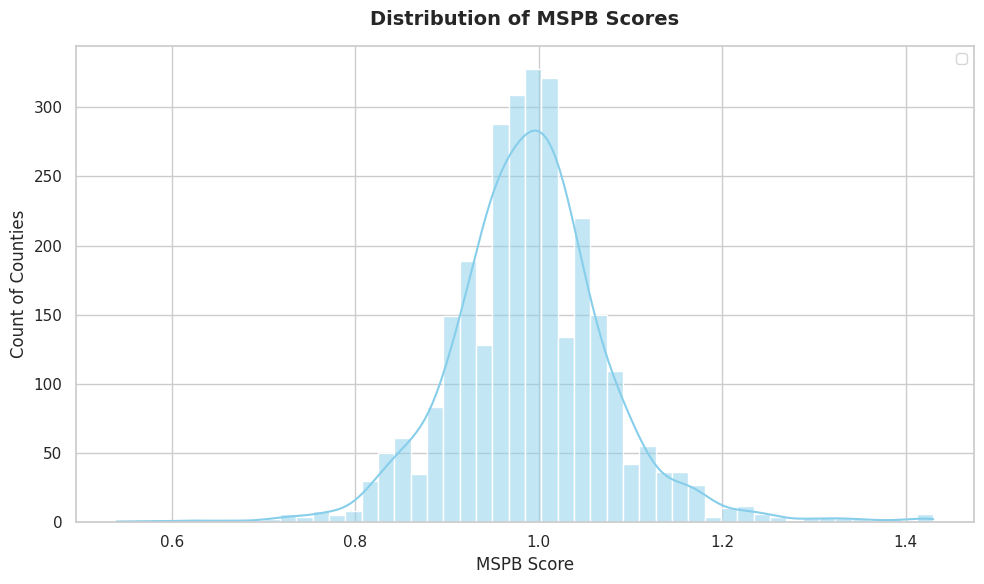

In [34]:
# Style background grid
sns.set_theme(style="whitegrid")

# Plot area
plt.figure(figsize=(10, 6))

# Plot the histogram with a Kernel Density Estimate (KDE) curve
sns.histplot(data=data, x='MSPB_score', kde=True, color='skyblue', bins=50)

# Format titles and labels
plt.title('Distribution of MSPB Scores', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('MSPB Score', fontsize=12)
plt.ylabel('Count of Counties', fontsize=12)
plt.legend(fontsize=10)

# Prevent labels/legends from clipping and display the finished visualization.
plt.tight_layout()
plt.show()

- This chart confirms that the MSPB scores for these counties are normally distributed (almost, there is a slight right skew), with the vast majority of counties spending close to the national average, and only a small percentage of counties showing significantly higher or lower spending

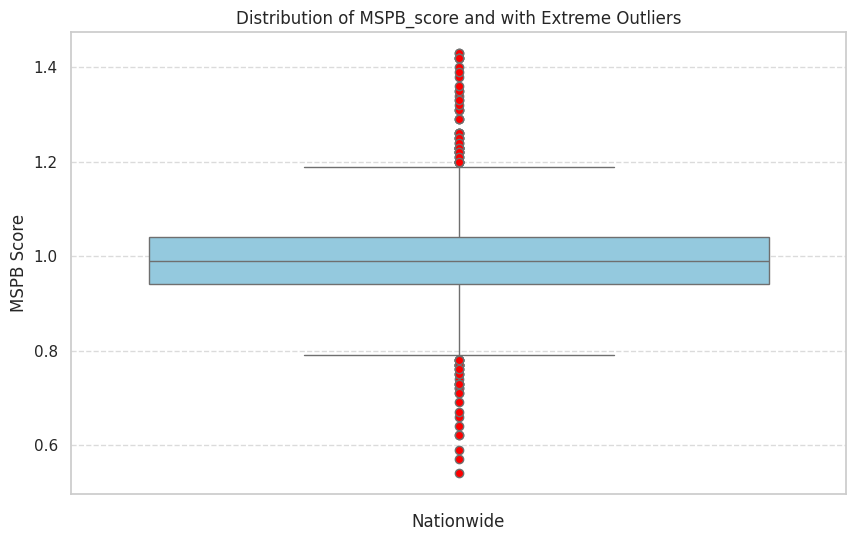

In [35]:
# Setup the figure size for better readability
plt.figure(figsize=(10, 6))

# Creating a Boxplot of the MSPB_score
# If you have many counties, you might want to plot the distribution 
# of the scores globally rather than grouping by county on the x-axis, 
# which would make the chart unreadable.
sns.boxplot(y=data['MSPB_score'], color='skyblue', flierprops={'markerfacecolor': 'red', 'marker': 'o'})

plt.title('Distribution of MSPB_score and with Extreme Outliers')
plt.ylabel('MSPB Score')
plt.xlabel('Nationwide')

# Add a grid for easier value reading
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### Breakdown

- **Central Tendency:** The majority of the data is clustered around the middle score of 1.0.

- **Symmetry:** The box is relatively centered, but the presence of many individual red dots at both the high and low ends suggests that while the 'bulk' of the data is concentrated, there is significant variability in the extreme values.

- **Extreme Cases:** The data set contains a notable number of extreme values (outliers) in both directions. This indicates that while 1.0 is the norm, there are specific instances or entities in this "Nationwide" data that perform or score much higher or lower than the rest of the group.

In [36]:
# Calculate thresholds
Q1 = data['MSPB_score'].quantile(0.25)        # Q1 is the cutoff point where the lowest 25% of your data ends
Q3 = data['MSPB_score'].quantile(0.75)        # Q3 is the point where the top 25% begins
IQR = Q3 - Q1                                 # Calculates middle 50% of data
lower_bound = Q1 - (1.5 * IQR)                # Calculates minimum value acceptable for data
upper_bound = Q3 + (1.5 * IQR)                # Calculates maximum value acceptable for data

# Filter outliers and sort once
# Identify rows where the score falls outside the established statistical boundaries.
outliers = (data['MSPB_score'] < lower_bound) | (data['MSPB_score'] > upper_bound)

# Filter the data using the mask and sort descending to highlight the most extreme values first.
sorted_outliers = data[outliers][['Facility Name','County/Parish', 'State', 'MSPB_score']].sort_values(by='MSPB_score', ascending=False)

# Print Summary Report
print(f"--- Analysis Report ---")
print(f"Total Counties Analyzed: {len(data)}")
print(f"Total Outliers Detected: {outliers.sum()}")
print(f"Thresholds -> Lower: {lower_bound:.2f} | Upper: {upper_bound:.2f}\n")

# Display Top 3 and Bottom 3
final_table = pd.concat([sorted_outliers.head(3), sorted_outliers.tail(3)])

print_header("EXTREME OUTLIERS (TOP 3 & BOTTOM 3)")
final_table

--- Analysis Report ---
Total Counties Analyzed: 5432
Total Outliers Detected: 88
Thresholds -> Lower: 0.79 | Upper: 1.19


            EXTREME OUTLIERS (TOP 3 & BOTTOM 3)             


,Facility Name,County/Parish,State,MSPB_score
575,GREATER EL MONTE COMMUNITY HOSPITAL,LOS ANGELES,CA,1.43
371,PARKVIEW COMMUNITY HOSPITAL MEDICAL CENTER,RIVERSIDE,CA,1.43
438,"GOOD SAMARITAN HOSPITAL, LP",KERN,CA,1.42
5399,ALTUS LUMBERTON HOSPITAL,HARDIN,TX,0.59
553,LAGUNA HONDA HOSPITAL & REHABILITATION CENTER,SAN FRANCISCO,CA,0.57
2672,WHITFIELD MEDICAL SURGICAL HOSPITAL,RANKIN,MS,0.54


#### Breakdown
- **Scope:** The analysis covered 5,432 counties or parishes nationwide.
- **Outlier Count:** Out of those, 88 locations were identified as statistical outliers.
- **Thresholds:** Any location with an MSPB score below 0.79 or above 1.19 was flagged as an outlier.  
These boundaries represent the "whiskers" seen in your previous box plot.

- **High Outliers (1.40+):** Counties like Los Angeles, Riverside, and Kern have outlier Medicare Spending per Beneficiary (MSPB) score facilities significantly higher than the average, these are not the average values here, they represent one individual hospital

- **Low Outliers (0.60 or below):** Inverse of the previous statement, counties like Hardin, San Francisco, and Rankin have facilities with MSPB scores significantly lower than the average.

In [37]:
# Plotting a map

# Aggregating data
# We have county-level data, we group by State to get a clean state-level view
state_data_spending = data.groupby('State')['MSPB_score'].mean().reset_index()

# Identify the Min and Max states
min_state = state_data_spending.loc[state_data_spending['MSPB_score'].idxmin()]
max_state = state_data_spending.loc[state_data_spending['MSPB_score'].idxmax()]

# Create a small DataFrame for the labels
extremes = pd.DataFrame([min_state, max_state])

# Create the Map
fig = px.choropleth(
    state_data_spending,
    locations='State',            # Column containing state abbreviations
    locationmode="USA-states",    # Tells Plotly these are US states
    color='MSPB_score',           # Column determining the hue
    scope="usa",                  # Limits the map to the US
    title='Average Spending Score by State',
    color_continuous_scale="Viridis",
    labels={'MSPB_score': 'Avg Spending Score'}
)

fig.update_layout(title_x=0.5, margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

Static copy of the interactive Plotly chart above, provided for GitHub compatibility where Plotly rendering may not display correctly.

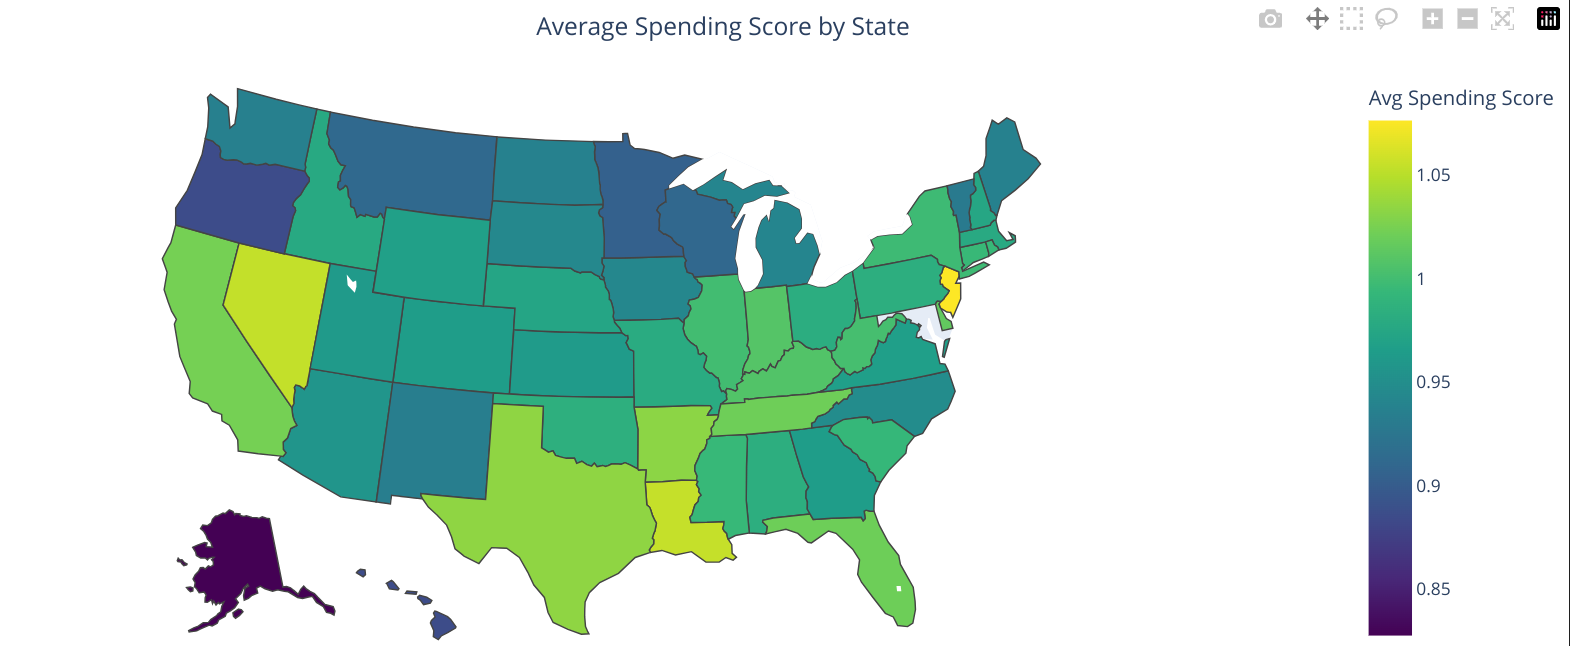

While most states maintain an average Medicare Spending Per Beneficiary (MSPB) score below the national benchmark of 1.0, significant variation exists  

For instance, New Jersey exhibits a higher average of 1.07, while Alaska sits at 0.82  

Importantly, these state-level averages often mask extreme individual facility performance, where some hospitals report spending scores as high as 1.43 (as seen in the previous table

**Note**: I used the arithmetic mean here because we are more interested in the total amount of money being spent instead of what the actual person is paying and thus the high-spending hospitals represent a significant part of our analysis.

#### Recap:
- MSPB scores across U.S. counties generally follow a normal distribution, with most facilities performing close to the national benchmark score of 1.0  

- Although the majority of values are concentrated around the median, the dataset contains a meaningful number of extreme outliers on both the high and low ends, indicating substantial variability in individual facility spending performance  

- Out of 5,432 counties/parishes analyzed, 88 locations were identified as statistical outliers, with MSPB scores falling outside the range of 0.79 to 1.19  

- Several hospitals in counties such as Los Angeles, Riverside, and Kern recorded significantly above-average MSPB scores, while facilities in Hardin, San Francisco, and Rankin showed notably lower spending scores  

- State-level analysis reveals regional variation in Medicare spending, with states like New Jersey averaging above the national benchmark and states like Alaska averaging below it  

- However, state averages can conceal substantial facility-level differences, emphasizing that localized hospital performance contributes heavily to overall spending variation nationwide.

### <center> Q2: The Value Gap: Create a scatter plot comparing Payment vs. Complications with Hue Hospital Ownership

In [38]:
data["Hospital Ownership"].value_counts()

Hospital Ownership
Voluntary non-profit - Private                 2316
Proprietary                                    1067
Government - Hospital District or Authority     516
Government - Local                              397
Voluntary non-profit - Other                    355
Voluntary non-profit - Church                   268
Government - State                              209
Veterans Health Administration                  132
Physician                                        81
Government - Federal                             43
Department of Defense                            32
Tribal                                           16
Name: count, dtype: int64

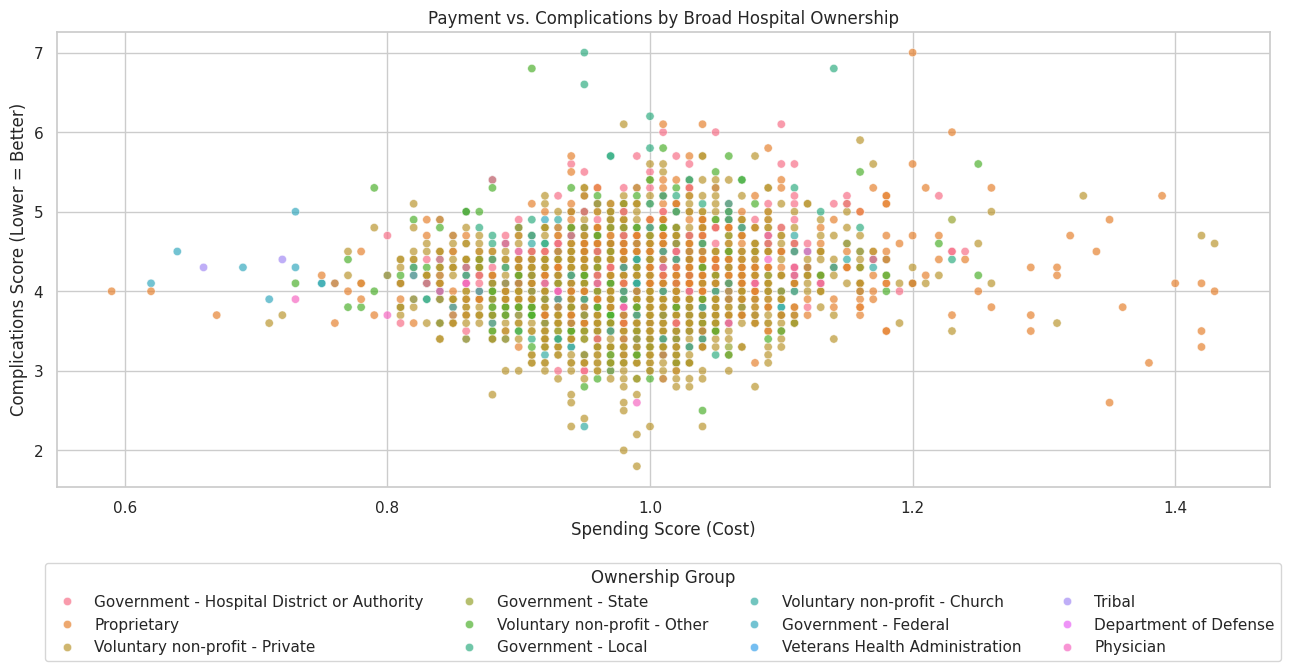

In [39]:
plt.figure(figsize=(14, 7))

# Use the new 'Ownership_Group' for the hue
sns.scatterplot(
    data=data,
    x='MSPB_score',
    y='Complications_score',
    hue='Hospital Ownership',
    alpha=0.7
)

plt.title('Payment vs. Complications by Broad Hospital Ownership')
plt.ylabel('Complications Score (Lower = Better)')
plt.xlabel('Spending Score (Cost)')

# Clean up legend placement
plt.legend(title='Ownership Group', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4)
plt.tight_layout()

plt.show()

This chart above was my initial EDA using Seaborn and all categorical labels, very obviously this a bit too much but it did make me remember the concept of Dimensions from class

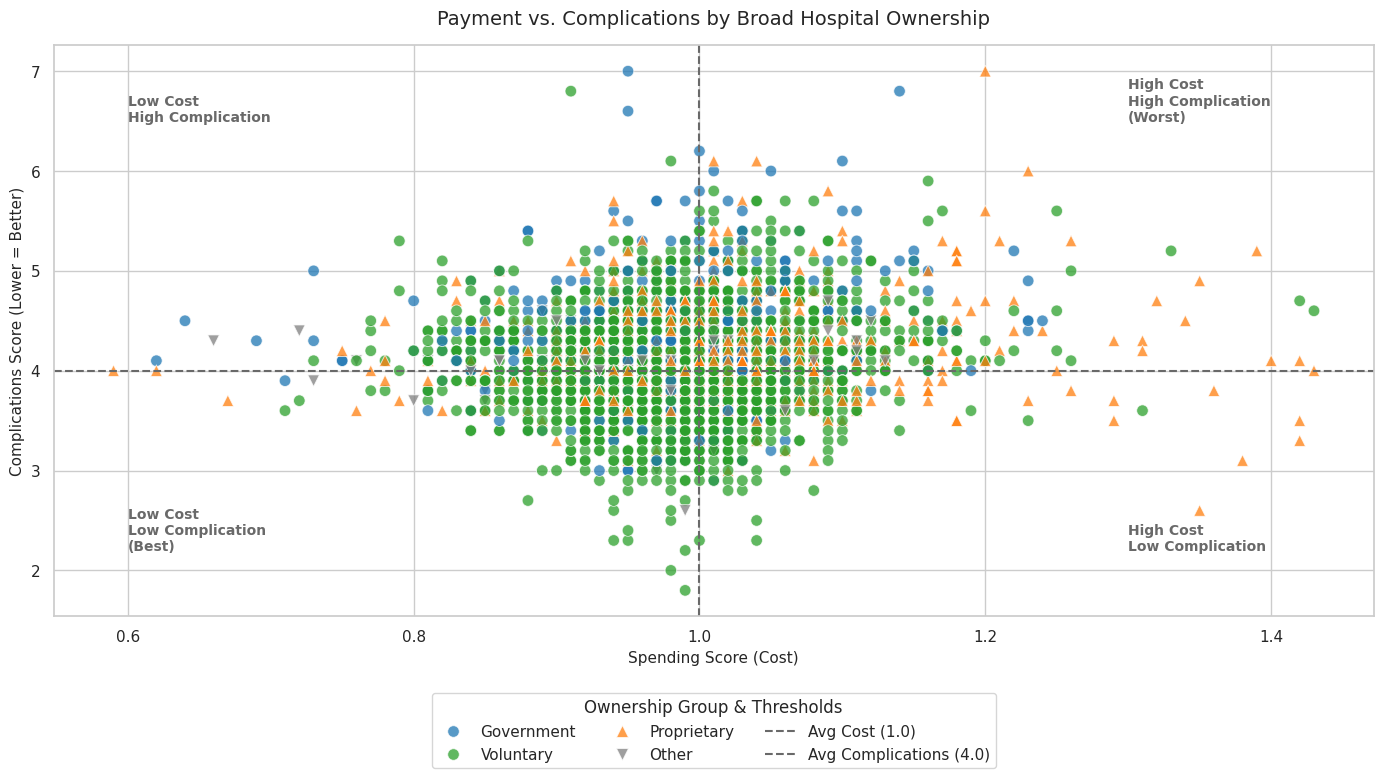

In [40]:
plt.figure(figsize=(14, 8))

# Explicitly define 4 highly distinct, accessible colors
custom_palette = {
    1: "#1f77b4",  # Blue - Government
    2: "#2ca02c",  # Green - Voluntary
    3: "#ff7f0e",  # Orange - Proprietary
    4: "#7f7f7f",  # Muted Gray - Other sections
}

# Define distinct marker shapes for each group
custom_markers = {
    1: "o",  # Circle
    2: "o",  # Bold X
    3: "^",  # Triangle
    4: "v",  # Downward Triangle
}

# Main Plot
sns.scatterplot(
    data=data,
    x="MSPB_score",
    y="Complications_score",
    hue="Ownership_encoded",
    style="Ownership_encoded",
    palette=custom_palette,
    markers=custom_markers,
    s=70,  # Marker size
    alpha=0.75,
)

# Threshold Lines (Creating 4 Quadrants)
plt.axvline(
    x=1.0, color="dimgray", linestyle="--", linewidth=1.5, label="Avg Cost (1.0)"
)
plt.axhline(
    y=4.0,
    color="dimgray",
    linestyle="--",
    linewidth=1.5,
    label="Avg Complications (4.0)",
)

# Quadrant Text Labels
plt.text(0.60,2.2,"Low Cost\nLow Complication\n(Best)",fontsize=10,color="dimgray", weight="bold")
plt.text(0.60, 6.5, "Low Cost\nHigh Complication", fontsize=10, color="dimgray", weight="bold")
plt.text(1.30, 2.2, "High Cost\nLow Complication", fontsize=10, color="dimgray", weight="bold")
plt.text(1.30, 6.5, "High Cost\nHigh Complication\n(Worst)", fontsize=10, color="dimgray", weight="bold")

plt.title("Payment vs. Complications by Broad Hospital Ownership", fontsize=14, pad=15)
plt.ylabel("Complications Score (Lower = Better)", fontsize=11)
plt.xlabel("Spending Score (Cost)", fontsize=11)

# Clean up and rename the legend manually
new_labels = [
    "Government",
    "Voluntary",
    "Proprietary",
    "Other",
    "Avg Cost (1.0)",
    "Avg Complications (4.0)",
]

# Fetch the current handles Seaborn generated, and map our clean text labels to them
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(
    handles=handles,
    labels=new_labels,
    title="Ownership Group & Thresholds",
    bbox_to_anchor=(0.5, -0.12),
    loc="upper center",
    ncol=3,  # Arranged in 3 columns for a balanced, compact look
    frameon=True,
)

plt.tight_layout()
plt.show()

#### My Observations

First things first, all that grouping and encoding work definitely paid off! The resulting chart is much cleaner and easier to read

Core metrics first:  
- X-Axis (Horizontal) — Spending Score (Cost): This measures how much a hospital spends relative to national benchmarks, Values greater than 1.0 indicate higher spending.
- Y-Axis (Vertical) — Complications Score: This tracks negative patient outcomes, lower is better; a lower score means fewer complications and safer patient care.

Looking at the distribution of the colored shapes reveals distinct operational trends among business models:

- Voluntary (Green Circles): These represent non-profit hospitals. Visually, they form the dense center mass of the data. They heavily populate the "Best"/bottom-left quadrant and are tightly clustered around the national averages, showing highly consistent performance

- Proprietary (Orange Triangles): These are for-profit hospitals. At first glance they pull significantly toward the right side of the chart. They are disproportionately represented in the higher-spending categories (above 1.2 on the X-axis) and despite their high cost, ironically, have a notable presence in the "Worst"/top-right quadrant

- Government (Blue Circles): Public/government hospitals are scattered fairly evenly across the middle spectrum, though they show a slight upward bias toward higher complication rates compared to the voluntary non-profit group

- Other (Gray Triangles): This catch-all group represents a tiny minority of the dataset (such as physician-owned or tribal facilities), appearing largely on the lower-spending left side of the chart.

### <center> Q3: Geographic Density: Identify the top 5 States with the highest average payment-to-quality ratio.

In [41]:
# Create payment_quality_ratio = MSPB_score × Complications_score
# (Zeros in Complications_score are converted to NaN to avoid infinity)
data["payment_quality_ratio"] = (
    data["MSPB_score"] * 
    data["Complications_score"].replace(0, np.nan)
)

# Calculate the average Payment-Quality Ratio by State
# Shows the top 5 best performing states
state_summary = (
    data.groupby("State")["payment_quality_ratio"]    # Group by State and select the ratio
    .mean()                                           # Calculate mean for each state
    .dropna()                                         # Remove states with no valid data
    .sort_values(ascending=False)
    .reset_index()
)
state_summary.columns = ["State", "Avg Payment-Quality Ratio"] # Rename columns for better readability

# Sorting in Descending order, worst will be first
state_summary = state_summary.sort_values(by="Avg Payment-Quality Ratio", ascending=False)

Payment-to-Quality Ratio: By multiplying these two scores (MSPB_score × Complications_score), the analysis creates a composite value.

Higher Ratio = Worse Value: Because both a high cost (high MSPB) and high complication rates (high Complications) are undesirable, a higher product indicates a combination of higher costs and lower quality of outcomes. This is why these are "Worse Value"

In [42]:
# Translate abbreviations into names for clarity
# Doing this manually for this project, for larger projects I would use a Library

state_names = {
    # Top 5 Best States
    "HI": "Hawaii",
    "MN": "Minnesota",
    "AK": "Alaska",
    "OR": "Oregon",
    "WA": "Washington",
    
    # Top 5 Worst States
    "MS": "Mississippi",
    "LA": "Louisiana",
    "AR": "Arkansas",
    "TN": "Tennessee",
    "AL": "Alabama"
}

state_summary["State_fullname"] = state_summary["State"].map(state_names)

In [43]:
# Isolate core metrics into a standalone view to prevent clutter in the final output.
payment_to_quality_table = state_summary[["State","State_fullname","Avg Payment-Quality Ratio"]].copy()

# Limit numeric precision to 3 decimal places
payment_to_quality_table["Avg Payment-Quality Ratio"] = payment_to_quality_table["Avg Payment-Quality Ratio"].round(2)

# Print output - 1
print_header("States with Highest Avg Payment-to-Quality Ratio (Higher = Worse Value)",100)
display(payment_to_quality_table.head())

# Print output - 2
print_header("States with Lowest Avg Payment-to-Quality Ratio (Lower = Better Value)",100)
display(payment_to_quality_table.tail().sort_values(by="Avg Payment-Quality Ratio",ascending=True))


              States with Highest Avg Payment-to-Quality Ratio (Higher = Worse Value)               


,State,State_fullname,Avg Payment-Quality Ratio
0,MS,Mississippi,4.89
1,LA,Louisiana,4.80
2,AR,Arkansas,4.63
3,TN,Tennessee,4.53
4,AL,Alabama,4.48



               States with Lowest Avg Payment-to-Quality Ratio (Lower = Better Value)               


,State,State_fullname,Avg Payment-Quality Ratio
49,HI,Hawaii,3.38
48,MN,Minnesota,3.47
47,AK,Alaska,3.47
46,OR,Oregon,3.55
45,WA,Washington,3.59


High Ratio = Bad: The hospital costs a lot of money, but has a low star rating. You are paying more for worse care.

Low Ratio = Good: The hospital is cost-efficient and has a high star rating. You are getting high-quality care for less money.

Table 1: States with the Highest Avg Ratio (The Worst Value)
These five states Mississippi, Louisiana, Arkansas, Tennessee and Alabama have the highest average ratios in the country (ranging from 4.89 to 4.48)

What this means: On average, hospitals in these states are either charging significantly more than the national average, delivering much lower quality of care (lower star ratings), or a combination of both

Table 2: States with the Lowest Avg Ratio (The Best Value)
These five states Hawaii, Minnesota, Alaska, Oregon and Washington have the lowest average ratios in the country (ranging from 3.38 to 3.59)

This means that these states offer the best overall value. Their hospitals are balancing the cost of care effectively with high patient outcomes and star ratings

In [44]:
# Map plot
fig = px.choropleth(
    state_summary,
    locations="State",                   # Column containing 2-letter state codes
    locationmode="USA-states",           # Tell Plotly to look for US state abbreviations
    color="Avg Payment-Quality Ratio",
    scope="usa",                         # Restrict map view to the USA
    color_continuous_scale="RdYlGn_r",   # Red-to-Yellow-Green scale, reversed (_r) so green = best/low ratio
    title="Average Hospital Payment-Quality Ratio by State",
    labels={"Avg Payment-Quality Ratio": "Avg Ratio (Lower is Better)"}
)

# Customize map appearance
fig.update_layout(
    title_x=0.5, # Center the title
    margin={"r":0, "t":50, "l":0, "b":0}
)

fig.show()

Static copy of the interactive Plotly chart above, provided for GitHub compatibility where Plotly rendering may not display correctly.

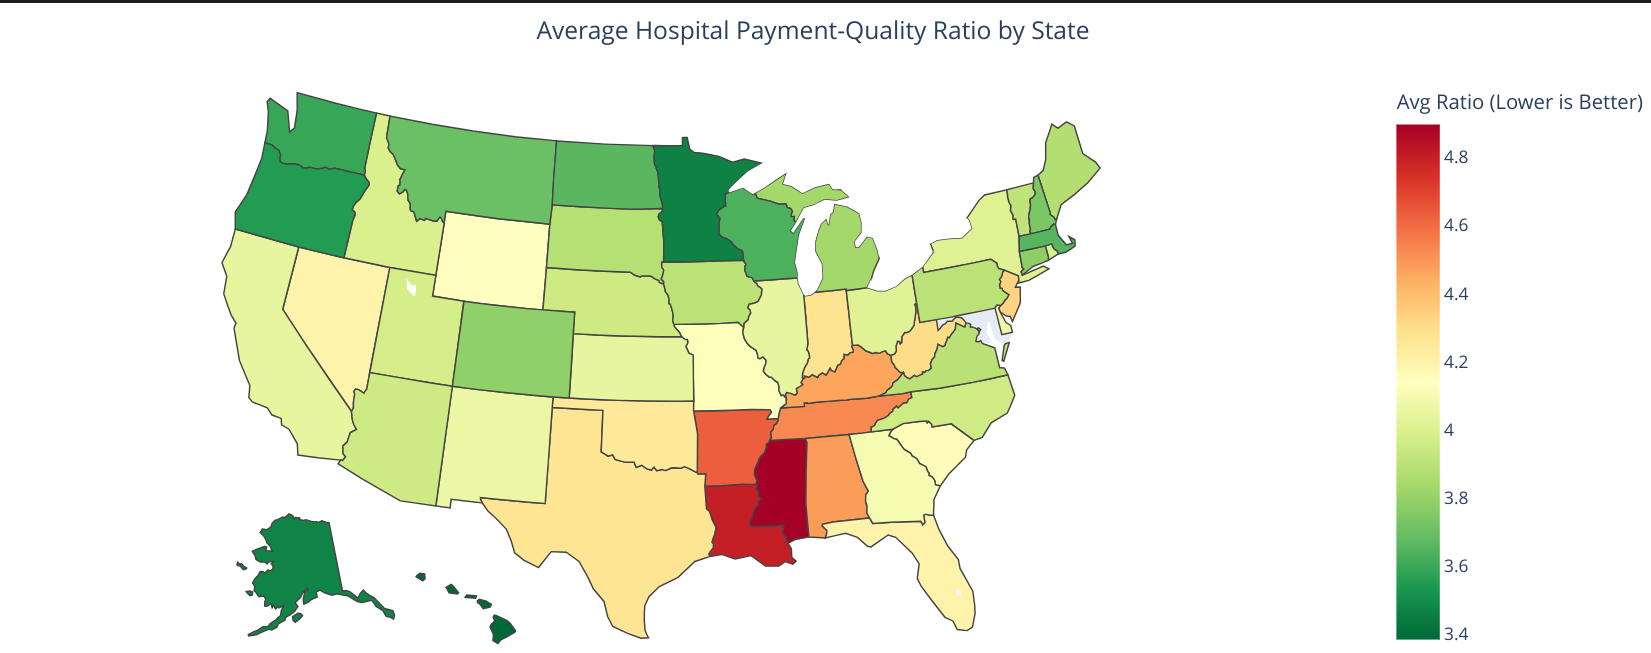

#### Breakdown of the Map:
The Legend
- Green (Lower Ratio = Better Value): These states represent high-quality care at a relatively lower cost
- Yellow/Light Green (Average): The middle of the pack, representing the baseline national average for hospital value
- Red/Orange (Higher Ratio = Worse Value): These states represent lower-quality care, higher relative costs, or both

Key Regional Insights
While tables gives raw numbers, the map highlights the now obvious spatial correlation, neighboring states share similar healthcare outcomes.

- The "Red Zone" (The Deep South): The most striking feature of the map is the heavy cluster of deep red and dark orange. You can easily spot Mississippi, Louisiana, Arkansas, Alabama, and Tennessee. Visually, it proves that the high payment-to-quality ratios are not isolated states, there is a systemic, regional challenge in that area regarding healthcare value

- The "Green Pioneers" (Pacific & Upper Midwest): The dark green states are on the Northwest (Washington and Oregon) along with Alaska and Hawaii forming a solid block of high-value care. Minnesota also stands out as a dark green in the Midwest

- The "Yellow" Middle America: Most of the Great Plains, Southwest, and Northeast fall into the light green and yellow categories,  their hospital value is relatively stable and close to the national average


## <center> Verdict

Short answer is cost and quality are entirely decoupled in the current US hospital landscape.

Paying more does not guarantee higher-quality care. In fact, cost and quality appear to be almost entirely decoupled across the US hospital landscape.

This conclusion is supported by three primary pieces of empirical evidence from our data:

1. The High Density of the "Value" Quadrant  
If quality required premium spending, the bottom-left quadrant (Low Cost / Low Complication) would be empty. Instead, it is heavily populated—primarily by Voluntary Non-Profit hospitals. These institutions prove that it is entirely possible to achieve superior clinical outcomes, fewer complications, while maintaining below-average spending.

2. The Presence of the "Worst" Quadrant  
If high costs bought better care, the top-right quadrant (High Cost / High Complication) would not exist. Yet, a significant cluster of hospitals—disproportionately represented by Proprietary, For-Profit institutions, fall into this space. These hospitals represent low-value care: they cost the healthcare system more, yet yield higher-than-average patient complications

3. Geographic Polarization (The State Ratios)  
Our state-level ratio ($\text{MSPB} \times \text{Complications}$) further cements this decoupling. If cost and quality were coupled, state averages would look uniform because higher costs would balance out with lower complications.  
Instead, we see massive geographic polarization:  
- States like Hawaii (HI) and Minnesota (MN) achieve highly efficient, low-ratio scores, proving systemic regional capability to deliver safe care cheaply
- States like Mississippi (MS) and Louisiana (LA) present alarmingly high ratios, signaling areas where spending fails to translate into patient safety

So, **price and performance do not move together in the current US system, higher cost does not necessarily buy better care**